# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download E-Commerce Sales Dataset](https://www.kaggle.com/datasets/jawadaahmed/e-commerce-sales-performance)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ecommerce_sales_data.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


## last Five row

In [4]:
df.tail()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28
3499,2024-11-01,Smartwatch,Electronics,East,9,10530,1777.32


## Shape of our dataset

In [5]:
df.shape

(3500, 7)

## List out all columns

In [6]:
df.columns

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Order Date       object
Product Name     object
Category         object
Region           object
Quantity          int64
Sales             int64
Profit          float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

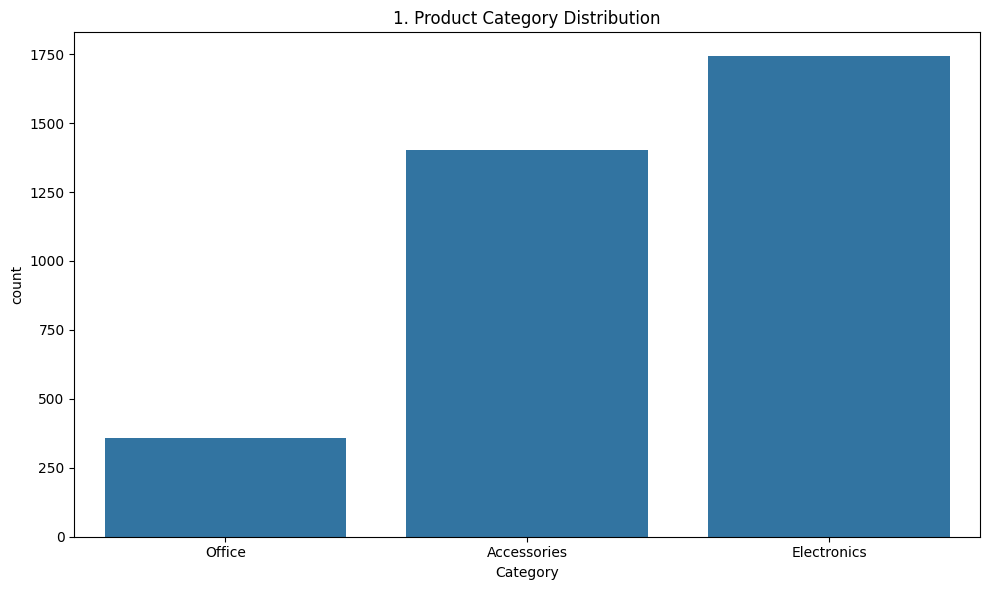

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Category")
plt.title(f'{plot_no}. Product Category Distribution')
show_fig()
plot_no += 1

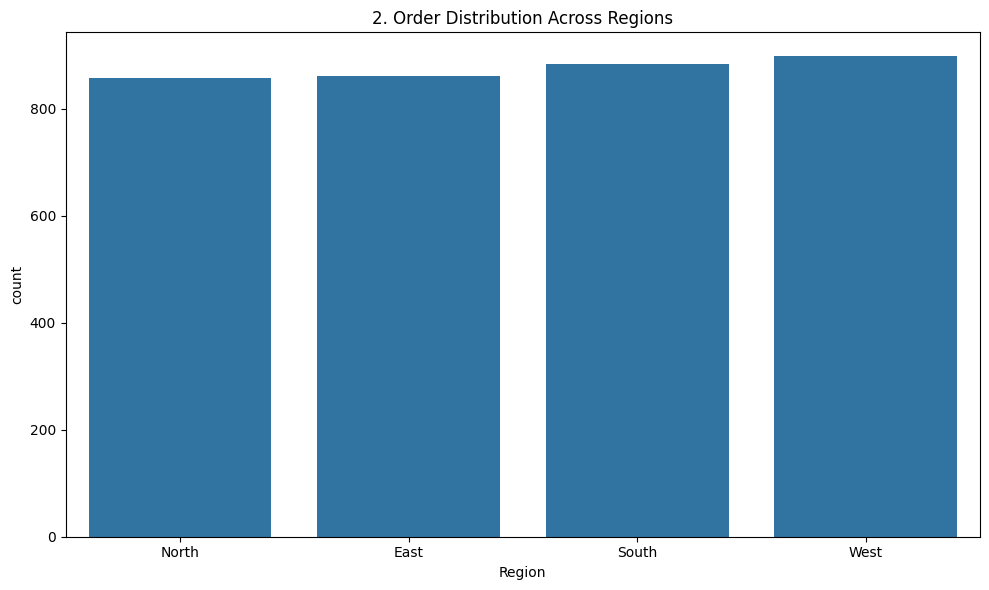

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Region")
plt.title(f'{plot_no}. Order Distribution Across Regions')
show_fig()
plot_no += 1

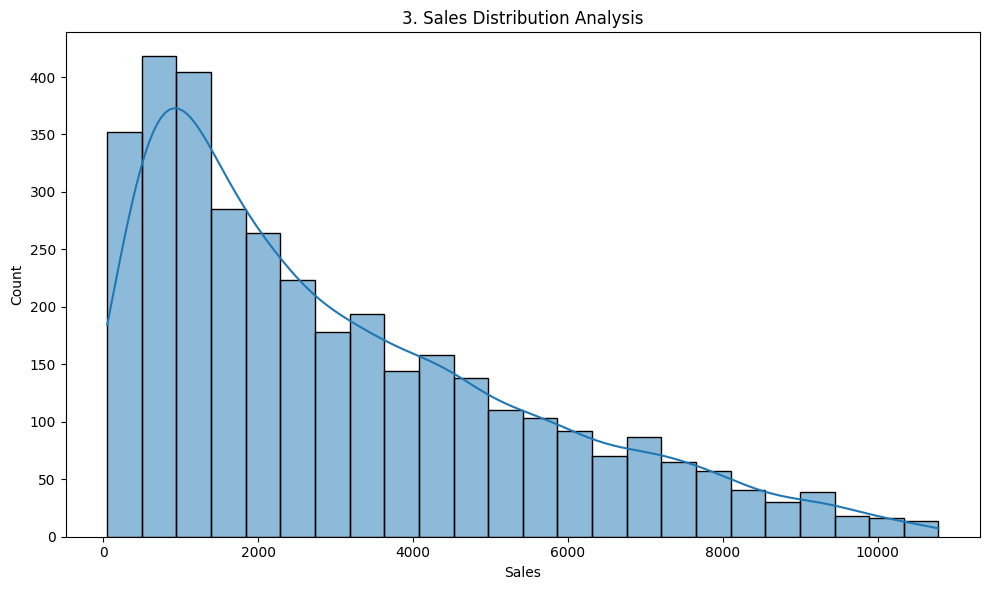

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df["Sales"], kde=True)
plt.title(f'{plot_no}. Sales Distribution Analysis')
show_fig()
plot_no += 1

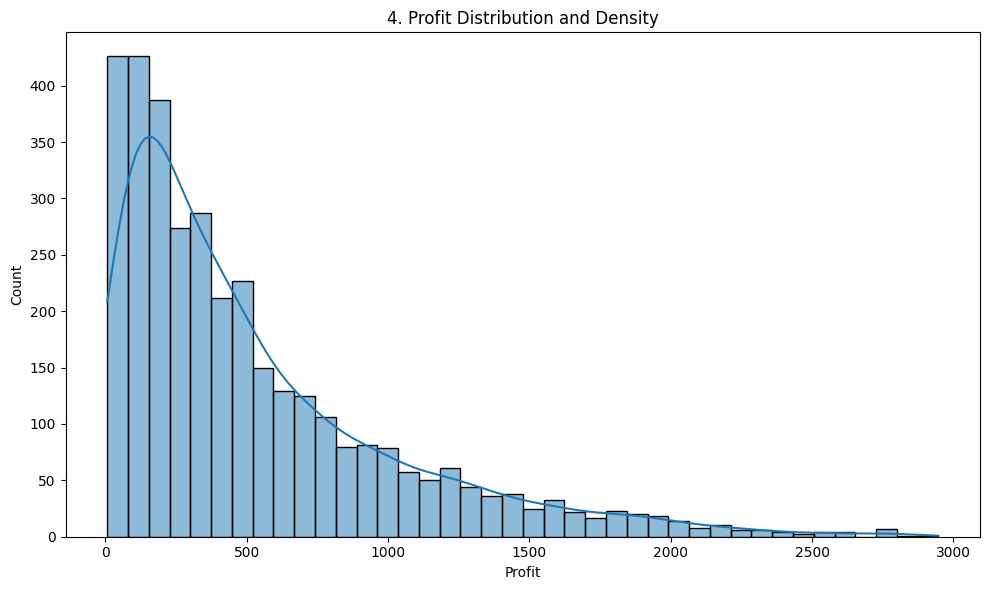

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df["Profit"], kde=True)
plt.title(f'{plot_no}. Profit Distribution and Density')
show_fig()
plot_no += 1

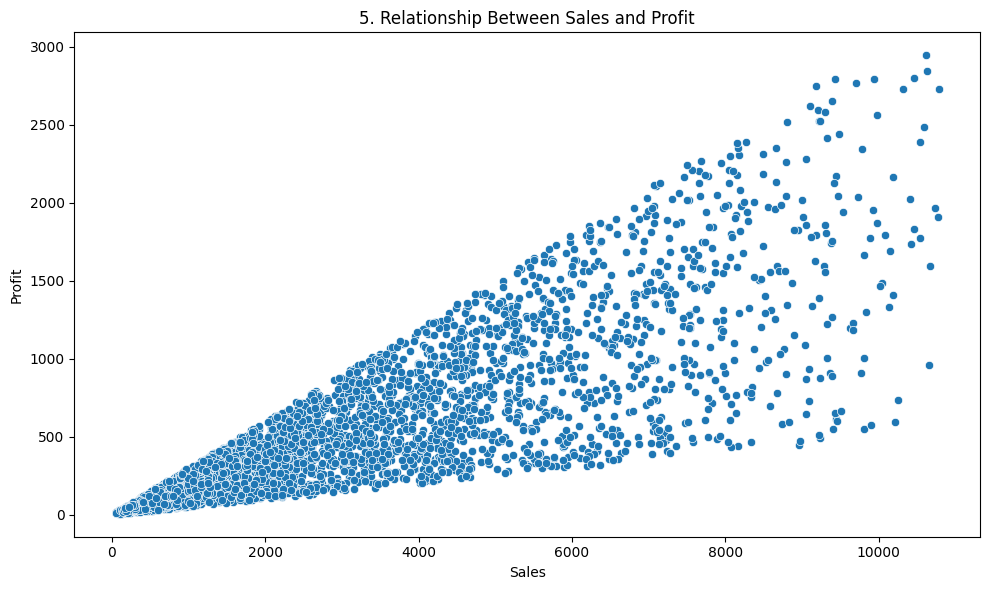

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Sales", y="Profit")
plt.title(f'{plot_no}. Relationship Between Sales and Profit')
show_fig()
plot_no += 1

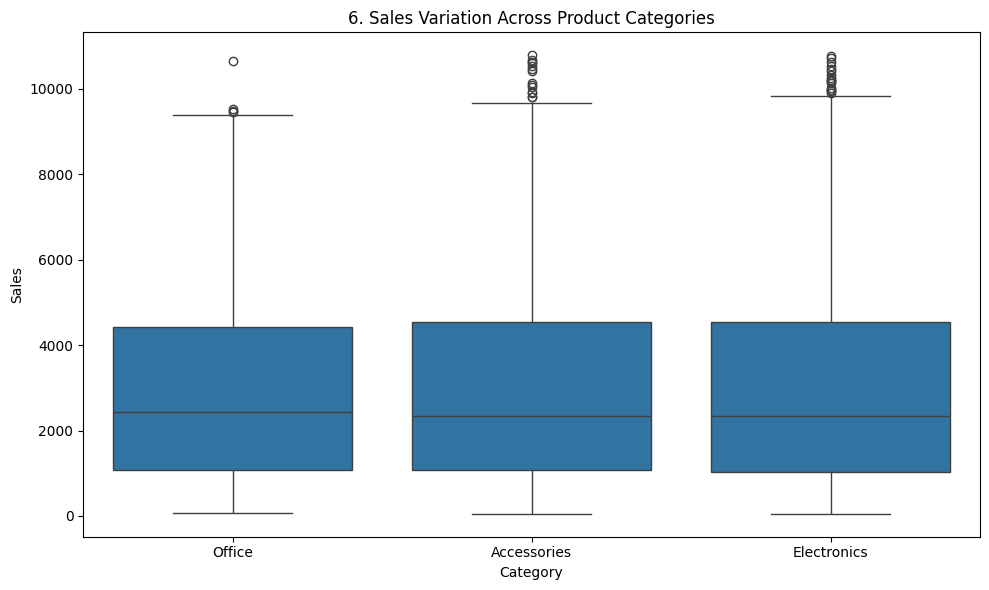

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Category", y="Sales")
plt.title(f'{plot_no}. Sales Variation Across Product Categories')
show_fig()
plot_no += 1

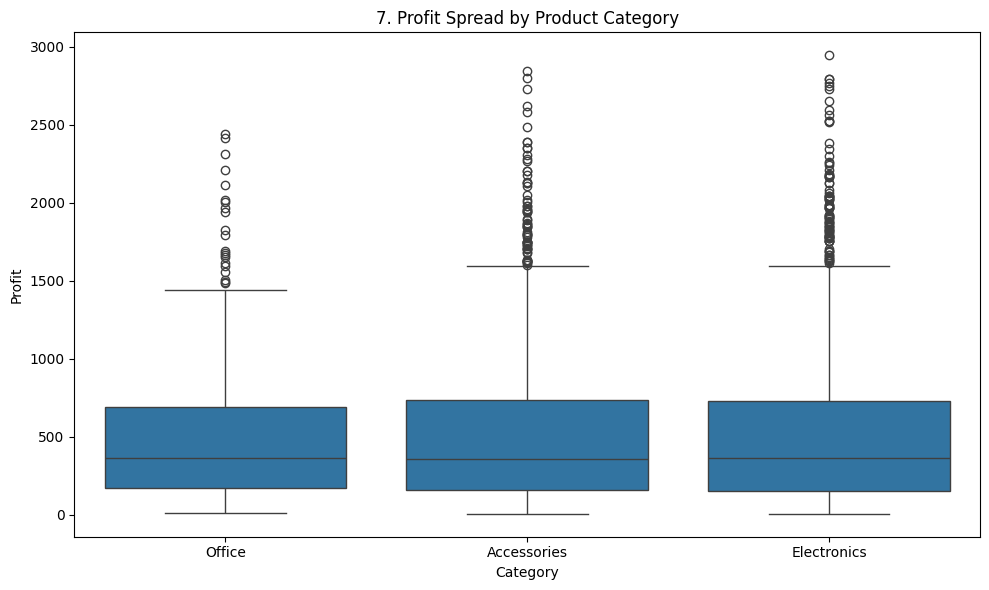

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Category", y="Profit")
plt.title(f'{plot_no}. Profit Spread by Product Category')
show_fig()
plot_no += 1

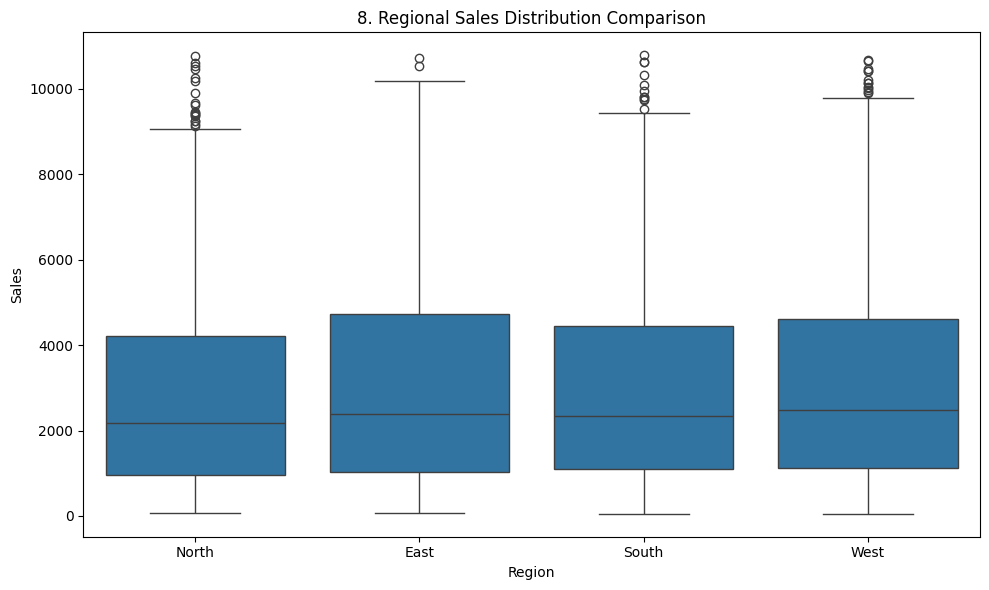

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Region", y="Sales")
plt.title(f'{plot_no}. Regional Sales Distribution Comparison')
show_fig()
plot_no += 1

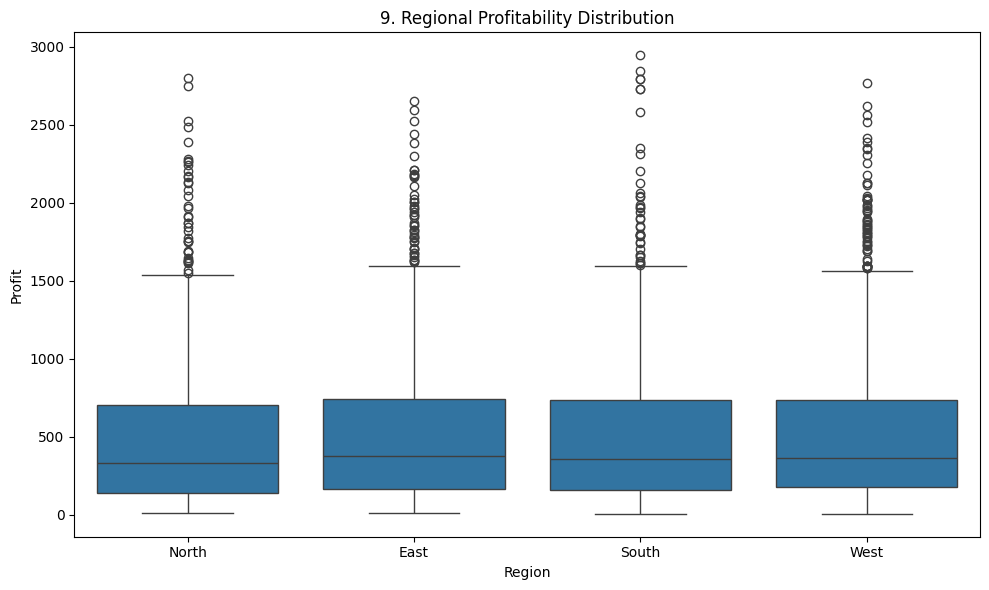

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Region", y="Profit")
plt.title(f'{plot_no}. Regional Profitability Distribution')
show_fig()
plot_no += 1

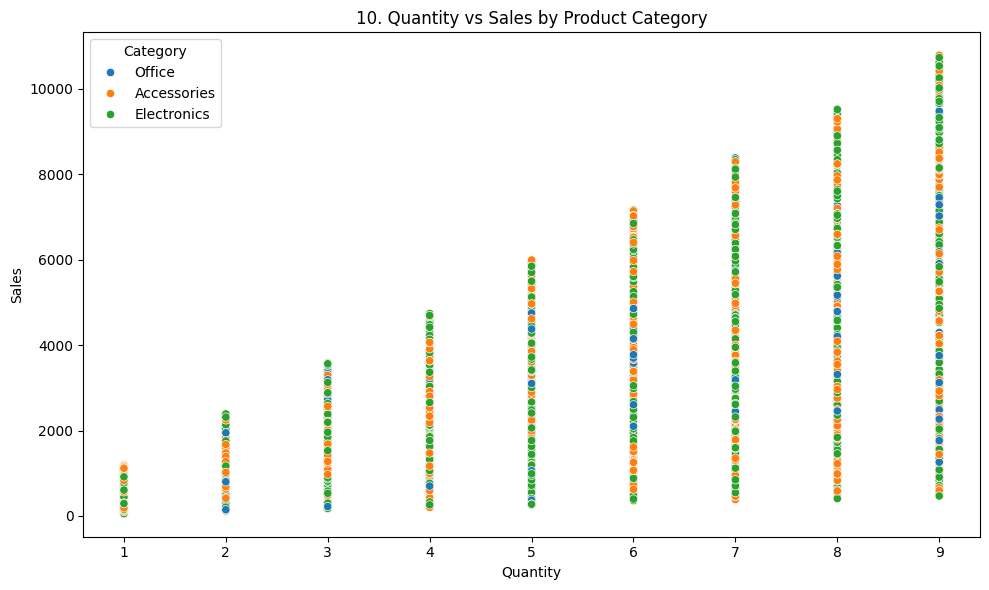

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Quantity", y="Sales", hue="Category")
plt.title(f'{plot_no}. Quantity vs Sales by Product Category')
show_fig()
plot_no += 1

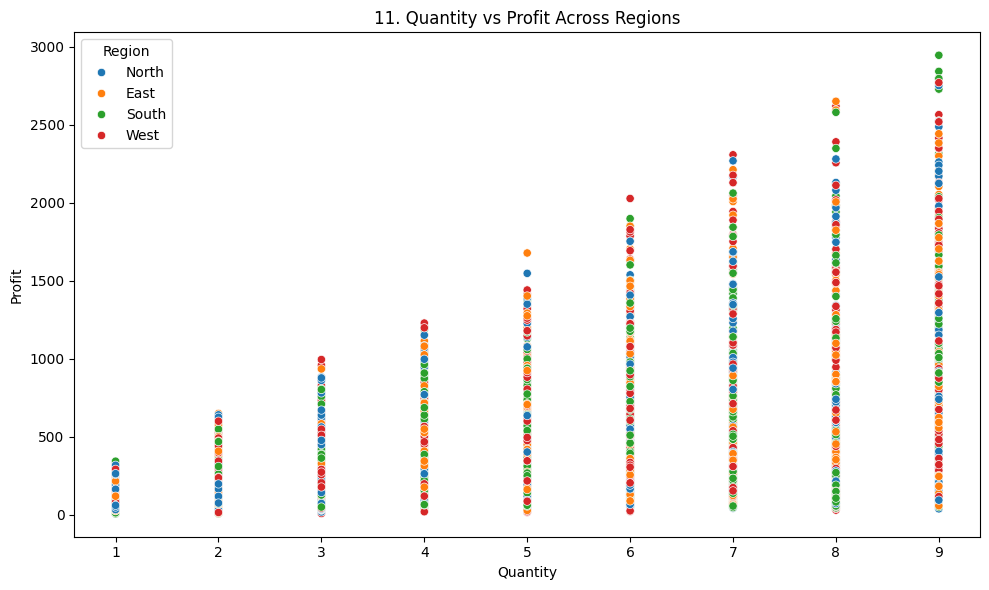

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Quantity", y="Profit", hue="Region")
plt.title(f'{plot_no}. Quantity vs Profit Across Regions')
show_fig()
plot_no += 1

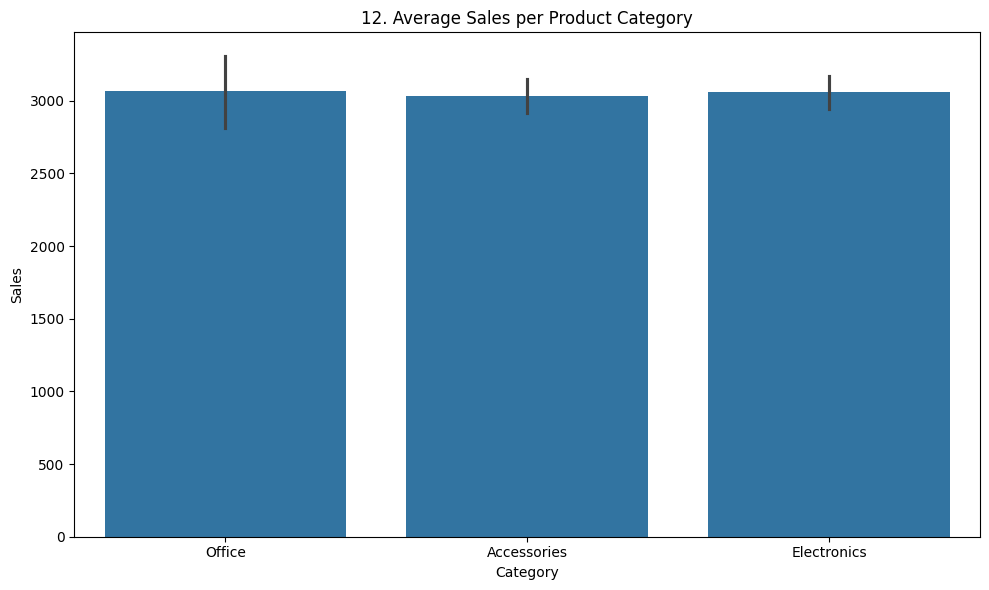

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Category", y="Sales", estimator=np.mean)
plt.title(f'{plot_no}. Average Sales per Product Category')
show_fig()
plot_no += 1

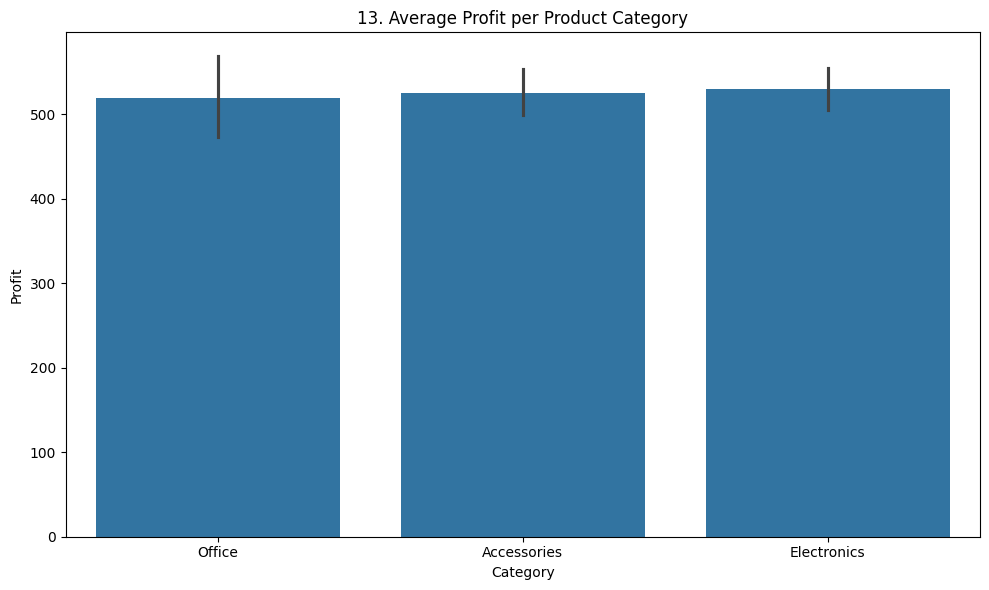

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Category", y="Profit", estimator=np.mean)
plt.title(f'{plot_no}. Average Profit per Product Category')
show_fig()
plot_no += 1

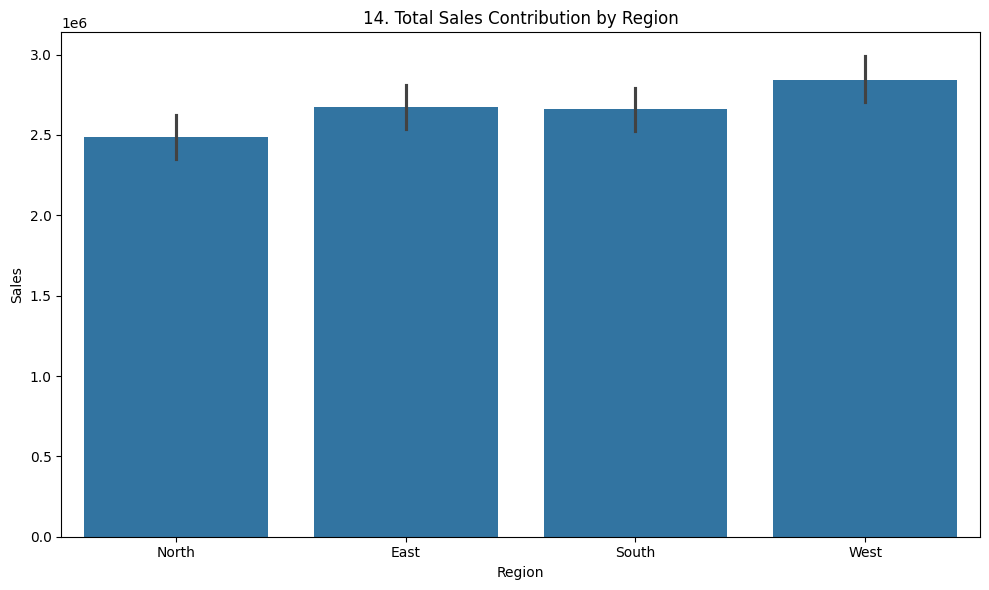

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Region", y="Sales", estimator=np.sum)
plt.title(f'{plot_no}. Total Sales Contribution by Region')
show_fig()
plot_no += 1

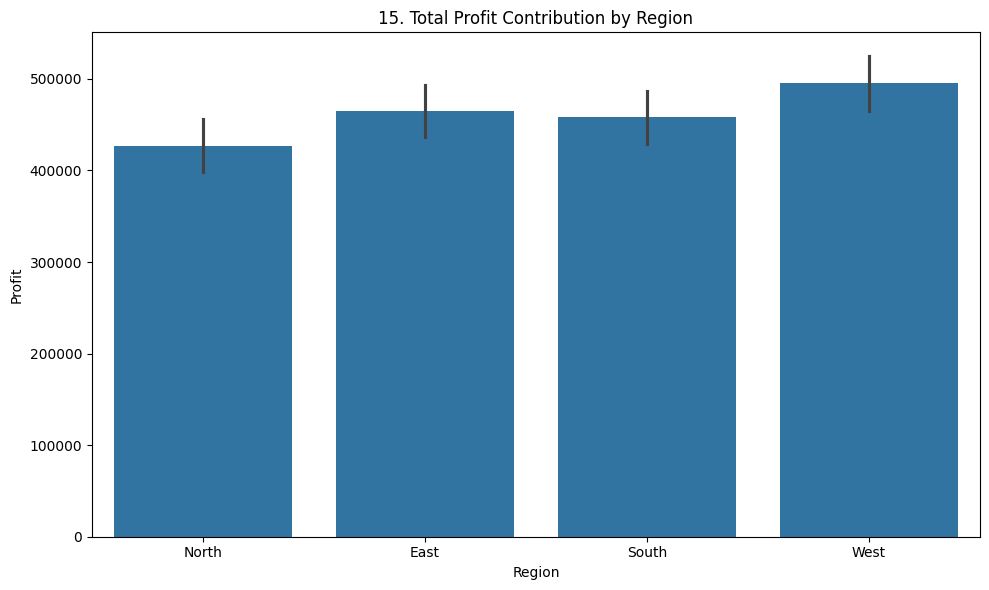

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Region", y="Profit", estimator=np.sum)
plt.title(f'{plot_no}. Total Profit Contribution by Region')
show_fig()
plot_no += 1

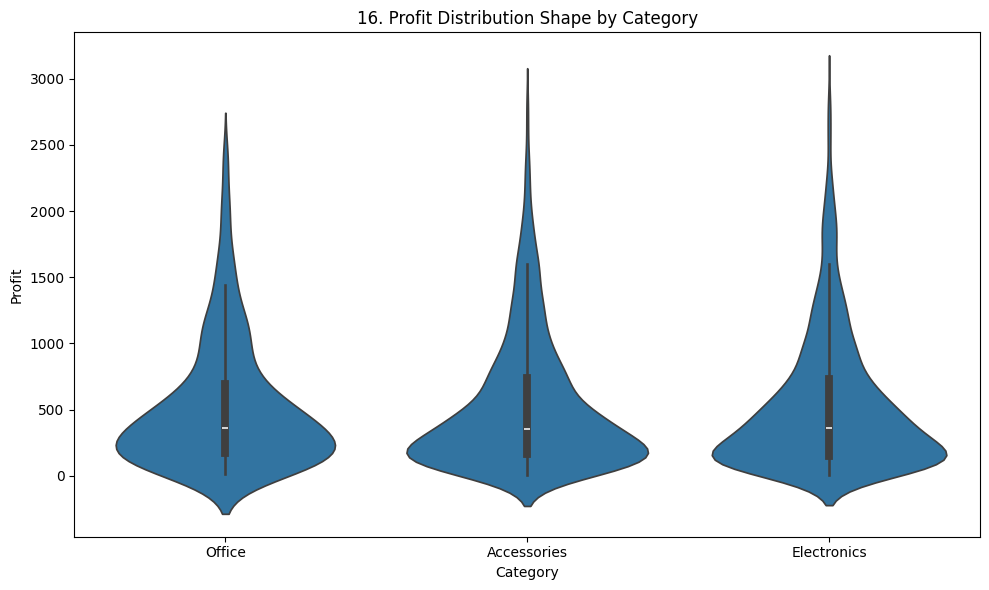

In [28]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="Category", y="Profit")
plt.title(f'{plot_no}. Profit Distribution Shape by Category')
show_fig()
plot_no += 1

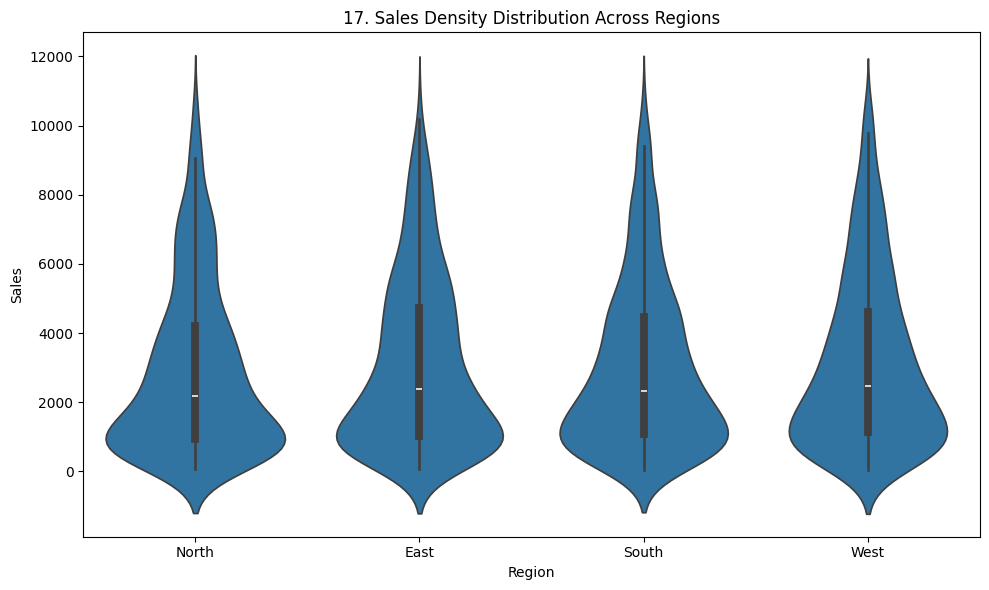

In [29]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="Region", y="Sales")
plt.title(f'{plot_no}. Sales Density Distribution Across Regions')
show_fig()
plot_no += 1

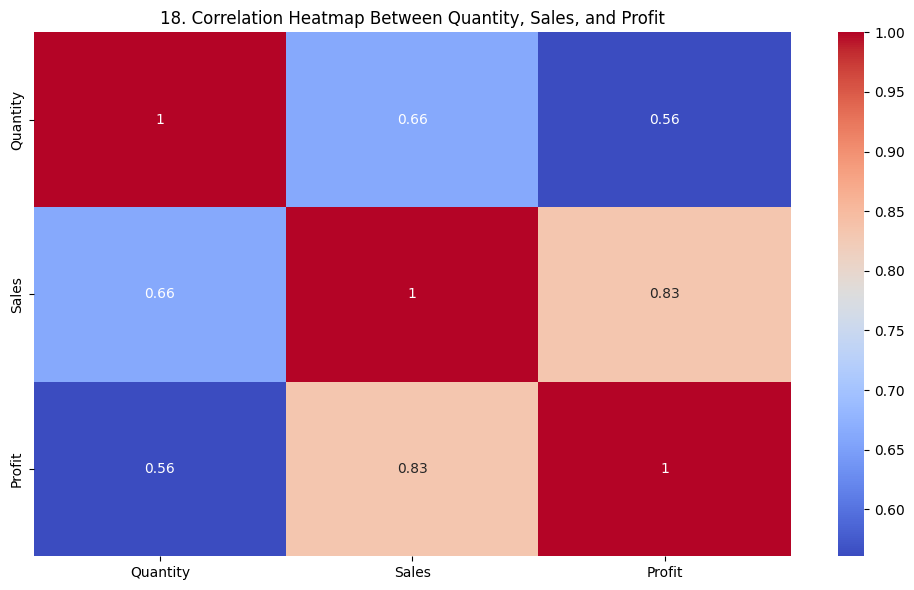

In [30]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df[["Quantity","Sales","Profit"]].corr(), annot=True, cmap="coolwarm")
plt.title(f'{plot_no}. Correlation Heatmap Between Quantity, Sales, and Profit')
show_fig()
plot_no += 1

# Model Training

## Encode categorical columns

In [31]:
le = LabelEncoder()
df["Product Name"] = le.fit_transform(df["Product Name"])
df["Category"] = le.fit_transform(df["Category"])
df["Region"] = le.fit_transform(df["Region"])

## Convert Order Date to numerical format

In [32]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Order Date"] = df["Order Date"].map(pd.Timestamp.toordinal)

## Create target variable (profit classification)

In [33]:
df["HighProfit"] = (df["Profit"] > df["Profit"].median()).astype(int)

## Select features and target

In [34]:
X = df[["Order Date","Product Name","Category","Region","Quantity","Sales"]]
y = df["HighProfit"]

## Split dataset into training and testing

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scale the feature values

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train supervised model (Logistic Regression)

In [37]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Predict on test data

In [38]:
y_pred = model.predict(X_test)

## Print model accuracy

In [39]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.8542857142857143


## Plot confusion matrix

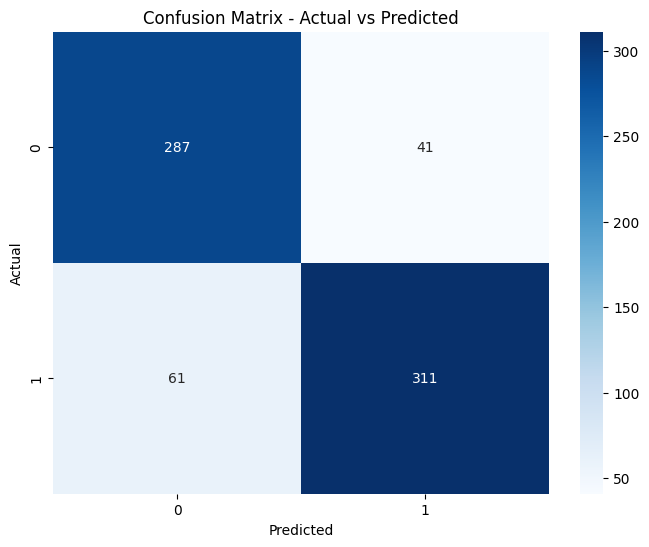

In [40]:
cm = confusion_matrix(y_test, y_pred)
fig = plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Actual vs Predicted")
plt.show()